## Análisis de Datos Meteorológicos con una API Pública
Obtener datos del clima de una ciudad usando la API de Open-Meteo (https://open-meteo.com/) y mostrar el pronóstico para Bilbao.

* Haz una petición a la API para que devuelva el pronóstico de las temperaturas para una semana en Bilbao. Tip: el parámetro correspondiente en el query es `temperature_2m` además de la latitud y la longitud.
* Procesa la respuesta en formato JSON para obtener dos listas: una con la lista de temperaturas y otra con las fechas-horas correspondientes.
* Crea un DataFrame con esas dos columnas: `Hora` y `Temperatura`
* Elige la gráfica adecuada y visualiza el pronóstico de temperaturas.

Para crear la variable `Hora` del DataFrame puedes introducir directamente la lista que se obtiene del campo `data["hourly"]["time"]` o procesar esa lista mediante el siguiente código:

`hours = pd.date_range(start=lista_de_horas, periods=len(temps), freq="H")`

In [12]:
import requests
import pandas as pd
import seaborn as sns


# Coordenadas de Kuna en Bilbao
latitude = 43.2540
longitude = -2.9230


url = f"https://api.open-meteo.com/v1/forecast?latitude=43.254&longitude=-2.923&hourly=temperature_2m&start_date=2026-03-23&end_date=2026-03-30"  # Aquí vienen el resto de los parámetros

In [5]:
#Poniendo los parámetros en la propia web genera la url para el query
url = f"https://api.open-meteo.com/v1/forecast?latitude=43.254&longitude=-2.923&hourly=temperature_2m&start_date=2026-03-23&end_date=2026-03-30"

response = requests.get(url)

#En postman se ve el formato en el que devuelve la información: dentro de "hourly" está "time" y "temperature_2m"
prediccion = response.json()
horas = prediccion ["hourly"]["time"]
temperaturas = prediccion ["hourly"]["temperature_2m"]


In [ ]:
#Comprobamos que horas se ha generado
horas

['2026-03-23T00:00',
 '2026-03-23T01:00',
 '2026-03-23T02:00',
 '2026-03-23T03:00',
 '2026-03-23T04:00',
 '2026-03-23T05:00',
 '2026-03-23T06:00',
 '2026-03-23T07:00',
 '2026-03-23T08:00',
 '2026-03-23T09:00',
 '2026-03-23T10:00',
 '2026-03-23T11:00',
 '2026-03-23T12:00',
 '2026-03-23T13:00',
 '2026-03-23T14:00',
 '2026-03-23T15:00',
 '2026-03-23T16:00',
 '2026-03-23T17:00',
 '2026-03-23T18:00',
 '2026-03-23T19:00',
 '2026-03-23T20:00',
 '2026-03-23T21:00',
 '2026-03-23T22:00',
 '2026-03-23T23:00',
 '2026-03-24T00:00',
 '2026-03-24T01:00',
 '2026-03-24T02:00',
 '2026-03-24T03:00',
 '2026-03-24T04:00',
 '2026-03-24T05:00',
 '2026-03-24T06:00',
 '2026-03-24T07:00',
 '2026-03-24T08:00',
 '2026-03-24T09:00',
 '2026-03-24T10:00',
 '2026-03-24T11:00',
 '2026-03-24T12:00',
 '2026-03-24T13:00',
 '2026-03-24T14:00',
 '2026-03-24T15:00',
 '2026-03-24T16:00',
 '2026-03-24T17:00',
 '2026-03-24T18:00',
 '2026-03-24T19:00',
 '2026-03-24T20:00',
 '2026-03-24T21:00',
 '2026-03-24T22:00',
 '2026-03-24T

In [8]:
df = pd.DataFrame ({"Hora": horas, "Temperatura": temperaturas})

In [ ]:
#Compruebo que está bien generado
df

,Hora,Temperatura
0,2026-03-23T00:00,12.3
1,2026-03-23T01:00,12.1
2,2026-03-23T02:00,11.8
3,2026-03-23T03:00,11.5
4,2026-03-23T04:00,11.1
...,...,...
187,2026-03-30T19:00,10.5
188,2026-03-30T20:00,10.4
189,2026-03-30T21:00,10.4
190,2026-03-30T22:00,10.3


<Axes: xlabel='Hora', ylabel='Temperatura'>

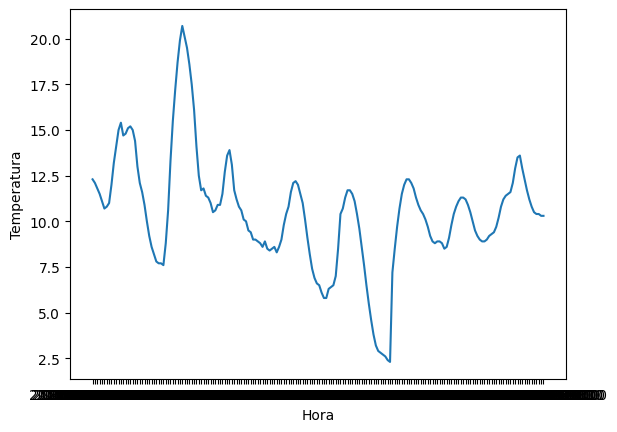

In [13]:
sns.lineplot (x= df["Hora"], y= df["Temperatura"])